# Renewables in Electricity Markets: System Perspective

This is the solution to Assignment 1 proposed in the course "Renewables in Electricity Markets" from DTU in 2025.

The chosen system is the IEEE 24-bus test reliability system, shown in the figure below. Data is in the file IEEE 24-bus reliability test system - data.xlsx. 

# ![System](img/System.png)

## Step 2: Copper-Plate, Multiple Hours

This step extends Step 1 by incorporating multiple time periods (here, 24 hours). Furthermore,
we now enforce intertemporal constraints by introducing a large-scale energy storage unit
(e.g., pumped hydro storage) into the case study. Also, we introduce generators technical constraints.

### Input data

In [24]:
# Import the libraries to be used
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import linopy
np.random.seed(42)

#### Read data

In [25]:
# system data
data = pd.read_excel('data/IEEE 24-bus reliability test system - data.xlsx', sheet_name=None)
print(data.keys())

dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])


In [26]:
#dict_keys(['Generators', 'Costs', 'SystemLoadProfile', 'LoadDist', 'BidTypes', 'Lines', 'WindFarms', 'LineModification'])
generators = data['Generators']
costs = data['Costs']
load_profile = data['SystemLoadProfile']
load_dist = data['LoadDist']
load_bid_types = data['BidTypes']
lines = data['Lines']
wind_farms = data['WindFarms']
line_modification = data['LineModification']

In [27]:
# windfarm data
wind_production_dk = pd.read_csv('data/ninja_wind_55.4104_12.3039_corrected.csv', skiprows=3)

#### Handle demand data

In [28]:
# Assign demand to each bus based on the load distribution
demand = load_profile.merge(load_dist, how='cross')
demand['Demand_MW'] = demand['System_demand_MW'] * demand['Percent_of_system_load'] / 100
demand['Hour'] = demand['Hour'] -1  # Adjust hour to be 0-indexed
demand.drop(columns=['System_demand_MW', 'Percent_of_system_load'], inplace=True)

In [29]:
# create demand bids: Load (id), Node (id), Quantity (MW), Price ($/MWh)
demand_bid = demand.merge(load_bid_types, left_on='Load_type', right_on='Load_type', how='left')
demand_bid['Quantity_MW'] = demand_bid['Demand_MW']*demand_bid['Quantity_perc']/100
demand_bid = demand_bid[['Bid', 'Load', 'Node', 'Hour', 'Load_type', 'Quantity_MW', 'Price_$/MWh']]
demand_bid['Load'] = 'L' + demand_bid['Load'].astype(str) 

#### Handle WindFarm data

In [30]:
#select 6 random days to simulate the wind production of each generator
np.random.seed(42)
wind_production_dk['local_time'] = pd.to_datetime(wind_production_dk['local_time'])
wind_production_dk['day'] = wind_production_dk['local_time'].dt.date
random_days = np.random.choice(wind_production_dk['day'].unique(), size=len(wind_farms), replace=False)
wind_production_sample = wind_production_dk[wind_production_dk['day'].isin(random_days)]
# assign one day to one zone windfarm
wind_production_sample['WindFarm'] = wind_production_sample['day'].apply(lambda x: random_days.tolist().index(x)+1)
wind_production_sample['Hour'] = wind_production_sample['local_time'].dt.hour

In [31]:
wind_forecast_generation = wind_production_sample.merge(wind_farms, on='WindFarm', how='left')
wind_forecast_generation['Generation_MW'] = wind_forecast_generation['Installed_Capacity_MW'] * wind_forecast_generation['electricity']
wind_forecast_generation = wind_forecast_generation[['WindFarm', 'Node', 'Hour', 'Generation_MW']].sort_values(['WindFarm', 'Hour'])
wind_forecast_generation['WindFarm'] = 'W' + wind_forecast_generation['WindFarm'].astype(str)
wind_forecast_generation.rename(columns={'Generation_MW': 'PForecast_MW', 'WindFarm': 'Unit'}, inplace=True)

#### Handle supply data

In [32]:
gen_constraints = generators.merge(costs, on='Unit')
gen_constraints['Unit'] = 'G' + gen_constraints['Unit'].astype(str)

### Modelling

In [33]:
# Sets
generators_set = pd.Index(gen_constraints['Unit'].unique(), name='Unit')
wind_farms_set = pd.Index(wind_forecast_generation['Unit'].unique(), name='Unit')
hours_set = pd.RangeIndex(0, 24, name='Hour')
loads_set = pd.Index(demand_bid['Load'].unique(), name='Load')
bids_set = pd.Index(demand_bid['Bid'].unique(), name='Bid')

In [34]:
# Parameters
gen_constraints_xr = gen_constraints.set_index('Unit').to_xarray()
demand_bid_xr = demand_bid.set_index(['Load','Bid','Hour']).to_xarray()
wind_forecast_xr = wind_forecast_generation.set_index(['Unit','Hour']).to_xarray()

pmax = gen_constraints_xr['Pmax_MW'] # Maximum power output of each generator in MW
ci = gen_constraints_xr['Ci_$/MWh'] # Variable cost of each generator in $/MWh

wind_forecast = wind_forecast_xr['PForecast_MW'] # Forecasted power output of each wind farm in MW

demand_quantity = demand_bid_xr['Quantity_MW'].reindex(
    Load=loads_set, 
    Bid=bids_set, 
    Hour=hours_set
).fillna(0)

demand_price = demand_bid_xr['Price_$/MWh'].reindex(
    Load=loads_set, 
    Bid=bids_set,
    Hour=hours_set
).fillna(0)

#### Model 1. Market clearing without technical constraints

In [35]:
model = linopy.Model()

# Decision variables: generation
g = model.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="dispatch"
)

# Decision variables: wind generation
w = model.add_variables(
    lower=0,
    coords=[wind_farms_set, hours_set],
    name="wind_generation"
)

# Decision variables: demand
d = model.add_variables(
    lower=0,
    coords=[loads_set, bids_set, hours_set],
    name="demand"
)

# Generators capacity constraints
capacity_constraints = model.add_constraints(
    g <= pmax,
    name="capacity_limit"
)

# Wind generation constraints
wind_constraints = model.add_constraints(
    w<= wind_forecast,
    name="wind_dispatch"
)

# Demand constraints
demand_constraints = model.add_constraints(
    d <= demand_quantity,
    name="demand_limit"
)

# Power balance constraint
balance = model.add_constraints(
    g.sum(dim="Unit") + w.sum(dim="Unit") == d.sum(dim=["Load","Bid"]),
    name="power_balance"
)

# Then use these in your objective
model.add_objective(
    (g * ci).sum() - (d * demand_price).sum(),
    sense="min"
)

model.solve(solver_name="highs")

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-fc5d3uep has 2088 rows; 2064 cols; 4128 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 6e+02]
Presolving model
24 rows, 1512 cols, 1512 nonzeros  0s
24 rows, 336 cols, 336 nonzeros  0s
Dependent equations search running on 24 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
24 rows, 336 cols, 336 nonzeros  0s
Presolve reductions: rows 24(-2064); columns 336(-1728); nonzeros 336(-3792) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
         24    -9.0998206670e+07 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-fc5d3uep
Model status        : Optimal

('ok', 'optimal')

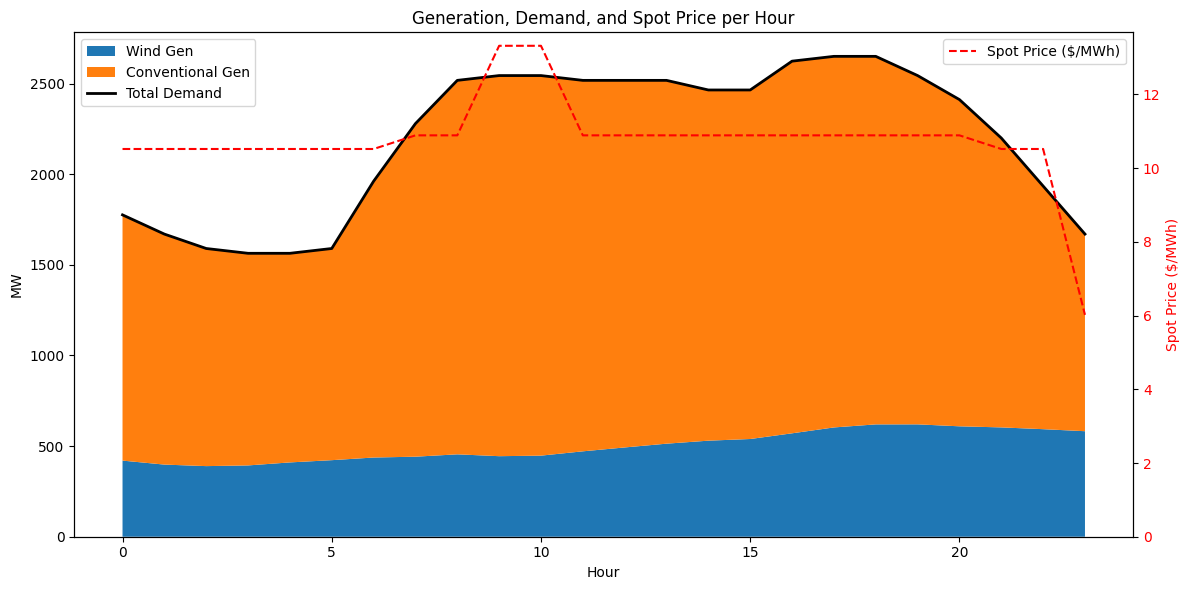

In [36]:
# Prepare data for plotting
import matplotlib.pyplot as plt

spot_price = balance.dual

# Wind generation (w) per hour
w_df = w.solution.to_dataframe().reset_index()
w_df = w_df.groupby('Hour')['solution'].sum().rename('Wind_MW')

# Generation (g) per hour
g_df = g.solution.to_dataframe().reset_index()
g_df = g_df.groupby('Hour')['solution'].sum().rename('Gen_MW')

# Total demand per hour
d_df = d.solution.to_dataframe().reset_index()
demand_per_hour = d_df.groupby('Hour')['solution'].sum().rename('Total_Demand_MW')

# Combine for stacked plot
gen_df = pd.concat([w_df, g_df], axis=1)

# Spot price per hour
spot_price_hourly = spot_price.values

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Stacked area for generation
ax1.stackplot(gen_df.index, gen_df['Wind_MW'], gen_df['Gen_MW'], labels=['Wind Gen', 'Conventional Gen'])
ax1.plot(demand_per_hour.index, demand_per_hour.values, color='black', label='Total Demand', linewidth=2)
ax1.set_xlabel('Hour')
ax1.set_ylabel('MW')
ax1.legend(loc='upper left')

# Spot price on secondary axis
ax2 = ax1.twinx()
ax2.plot(range(24), spot_price_hourly, 'r--', label='Spot Price ($/MWh)')
ax2.set_ylabel('Spot Price ($/MWh)', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')
ax2.set_ylim(bottom=0)  # Ensure spot price starts at 0

plt.title('Generation, Demand, and Spot Price per Hour')
plt.tight_layout()
plt.show()

#### Model 2. Adding technical constraints

In this step we add technical constraints of ramping limits and minimum generation levels. For this, we need to solve the problem twice: first, we impose the technical constraints and solve the problem to find the optimal value for the binary variables. Then, we fix the binary variables to their optimal value and solve the problem again to find the optimal generation levels and market clearing price.

* Note: This step was not required in the assignment.

In [37]:
# Additional parameters
pmin = gen_constraints_xr['Pmin_MW'] # Minimum power output of each generator in MW
rplus = gen_constraints_xr['Rplus_MW'] # Reserve up capacity of each generator in MW
rminus = gen_constraints_xr['Rminus_MW'] # Reserve down capacity of each generator in MW
ru = gen_constraints_xr['RU_MW_per_h'] # Ramp up limit of each generator in MW per hour
rd = gen_constraints_xr['RD_MW_per_h'] # Ramp down limit of each generator in MW per hour
cu = gen_constraints_xr['Cu_$/MWh'] # Upward reserve capacity cost of each generator in $/MWh
cd = gen_constraints_xr['Cd_$/MWh'] # Downward reserve capacity cost of each generator in $/MWh
cplus = gen_constraints_xr['Cplus_$/MWh'] # Up regulation offer price of each generator in $/MWh
cminus = gen_constraints_xr['Cminus_$/MWh'] # Down regulation offer price of each generator in $/MWh
csu = gen_constraints_xr['Csu_$'] # Start-up cost of each generator in $
pini = gen_constraints_xr['Pini_MW'] # Initial power output of each generator in MW
uini = gen_constraints_xr['Uini_0_1'] # Initial online/offline status of each generator (0 or 1)
tini = gen_constraints_xr['Tini_h'] # Initial time each generator has been in its current state (hours)

In [38]:
# New aux model: MILP including technical constraints

model2_aux = linopy.Model()

# Decision variables: generation
g2_aux = model2_aux.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="dispatch"
)

# Decision variable: ramp up
g2_up_aux = model2_aux.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="ramp_up"
)

# Decision variable: ramp down
g2_down_aux = model2_aux.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="ramp_down"
)

# Decision variable: start-up (binary)
su2_aux = model2_aux.add_variables(
    coords=[generators_set, hours_set],
    binary=True,
    name="start_up"
)

# Decision variables: wind generation
w2_aux = model2_aux.add_variables(
    lower=0,
    coords=[wind_farms_set, hours_set],
    name="wind_generation"
)

# Decision variables: unit commitment (binary)
u2_aux = model2_aux.add_variables(
    coords=[generators_set, hours_set],
    binary=True,
    name="unit_commitment"
)

# Decision variables: demand
d2_aux = model2_aux.add_variables(
    lower=0,
    coords=[loads_set, bids_set, hours_set],
    name="demand"
)

# Capacity constraints
capacity_constraint2_aux = model2_aux.add_constraints(
    g2_aux <= pmax * u2_aux,
    name="capacity_limit"
)

# Minimum generation constraints
min_generation_constraint2_aux = model2_aux.add_constraints(
    g2_aux >= pmin * u2_aux,
    name="min_generation_constraint"
)

# Demand constraints
demand_constraint2_aux = model2_aux.add_constraints(
    d2_aux <= demand_quantity,
    name="demand_limit"
)

# Power balance constraint
power_balance_constraint2_aux = model2_aux.add_constraints(
    g2_aux.sum(dim="Unit") == d2_aux.sum(dim=["Load", "Bid"]),
    name="power_balance"
)

################## Ramps ###################

#### Ramp up

# Ramp up for hour 0
ramp_up_h0_2_aux = model2_aux.add_constraints(
    g2_aux.sel(Hour=0) - pini * uini <= g2_up_aux.sel(Hour=0),
    name="ramp_up_h0"
)

# Ramp up for hours > 0
ramp_up2_aux = model2_aux.add_constraints(
    g2_aux.diff(dim="Hour").sel(Hour=slice(1, None))<= g2_up_aux.sel(Hour=slice(1, None)),
    name="ramp_up"
)

# ramp up limit
ramp_up_limit2_aux = model2_aux.add_constraints(
    g2_up_aux <= ru,
    name="ramp_up_limit"
)

#### Ramp down
# Ramp down for hour 0
ramp_down_h0_2_aux = model2_aux.add_constraints(
    g2_aux.sel(Hour=0) - pini * uini >= -g2_down_aux.sel(Hour=0),
    name="ramp_down_h0"
)

# Ramp down for hours > 0
ramp_down2_aux = model2_aux.add_constraints(
    g2_aux.diff(dim="Hour").sel(Hour=slice(1, None)) >= -g2_down_aux.sel(Hour=slice(1, None)),
    name="ramp_down"
)

# Ramp down limit
ramp_down_limit2_aux = model2_aux.add_constraints(
    g2_down_aux <= rd,
    name="ramp_down_limit"
)

########### Start-up constraints ###########

# Start-up constraints for hour 0
startup_h0_2_aux = model2_aux.add_constraints(
    su2_aux.sel(Hour=0) == u2_aux.sel(Hour=0) - uini,
    name="startup_h0"
)

# Start-up constraints for hours > 0
startup2_aux = model2_aux.add_constraints(
    su2_aux.sel(Hour=slice(1, None)) == u2_aux.diff(dim="Hour").sel(Hour=slice(1, None)),
    name="startup"
)

# Objective: minimize generation costs (including ramps and start-up costs) minus demand benefits

epsilon = 1e-6

production_cost = (g2_aux * ci).sum()
ramp_up_cost = (g2_up_aux * (cplus+epsilon)).sum()
ramp_down_cost = (g2_down_aux * (cminus+epsilon)).sum()
startup_cost = (su2_aux * (csu+epsilon)).sum()
demand_utility = (d2_aux * demand_price).sum()

model2_aux.add_objective(
    production_cost + ramp_up_cost + ramp_down_cost + startup_cost - demand_utility,
    sense="min"
)

model2_aux.solve(solver_name="highs")


Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
MIP linopy-problem-gug3nwjm has 3672 rows; 3216 cols; 7836 nonzeros; 576 integer variables (576 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+02]
  Cost    [1e-06, 3e+03]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 4e+02]
Presolving model
1264 rows, 2128 cols, 4108 nonzeros  0s
774 rows, 1998 cols, 3564 nonzeros  0s
753 rows, 1017 cols, 2689 nonzeros  0s
753 rows, 1017 cols, 2689 nonzeros  0s
Presolve reductions: rows 753(-2919); columns 1017(-2199); nonzeros 2689(-5147) 

Solving MIP model with:
   753 rows
   1017 cols (113 binary, 0 integer, 0 implied int., 904 continuous, 0 domain fixed)
   2689 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Roun

('ok', 'optimal')

In [39]:
# Rewrite the model but use the results of the binary variables of the aux model

model2 = linopy.Model()

# Use the results of the binary variables from the aux model
u2_values = u2_aux.solution.copy()
su2_values = su2_aux.solution.copy()

# Decision variables: generation
g2 = model2.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="dispatch"
)

# Decision variable: ramp up
g2_up = model2.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="ramp_up"
)

# Decision variable: ramp down
g2_down = model2.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="ramp_down"
)

# Wind generation variables
w2 = model2.add_variables(
    lower=0,
    coords=[wind_farms_set, hours_set],
    name="wind_generation"
)

# Demand variables
d2 = model2.add_variables(
    lower=0,
    coords=[loads_set, bids_set, hours_set],
    name="demand"
)

# Capacity constraints using fixed unit commitment
capacity_limit2 = model2.add_constraints(
    g2 <= pmax * u2_values,
    name="capacity_limit"
)

# Minimum generation constraints using fixed unit commitment
min_generation_constraint2 = model2.add_constraints(
    g2 >= pmin * u2_values,
    name="min_generation_constraint"
)

# Wind generation constraints
wind_constraints2 = model2.add_constraints(
    w2 <= wind_forecast,
    name="wind_dispatch"
)

# Demand constraints
demand_limit2 = model2.add_constraints(
    d2 <= demand_quantity,
    name="demand_limit"
)

# Power balance constraint
power_balance_constraint2 = model2.add_constraints(
    g2.sum(dim="Unit") + w2.sum(dim="Unit") == d2.sum(dim=["Load", "Bid"]),
    name="power_balance"
)

################## Ramps ###################

# Ramp up for hour 0
ramp_up_h0_2 = model2.add_constraints(
    g2.sel(Hour=0) - pini * uini <= g2_up.sel(Hour=0),
    name="ramp_up_h0"
)

# Ramp up for hours > 0
ramp_up2 = model2.add_constraints(
    g2.diff(dim="Hour").sel(Hour=slice(1, None)) <= g2_up.sel(Hour=slice(1, None)),
    name="ramp_up"
)

# Ramp up limit
ramp_up_limit2 = model2.add_constraints(
    g2_up <= ru,
    name="ramp_up_limit"
)

# Ramp down for hour 0
ramp_down_h0_2 = model2.add_constraints(
    g2.sel(Hour=0) - pini * uini >= -g2_down.sel(Hour=0),
    name="ramp_down_h0"
)

# Ramp down for hours > 0
ramp_down2 = model2.add_constraints(
    g2.diff(dim="Hour").sel(Hour=slice(1, None)) >= -g2_down.sel(Hour=slice(1, None)),
    name="ramp_down"
)

# Ramp down limit
ramp_down_limit2 = model2.add_constraints(
    g2_down <= rd,
    name="ramp_down_limit"
)

# Objective: minimize generation costs (including ramps and start-up costs) minus demand benefits
production_cost = (g2 * ci).sum()
ramp_up_cost = (g2_up * cplus).sum()
ramp_down_cost = (g2_down * cminus).sum()
demand_utility = (d2 * demand_price).sum()

model2.add_objective(
    production_cost + ramp_up_cost + ramp_down_cost - demand_utility,
    sense="min"
)

model2.solve(solver_name="highs")

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-fh9l5fqc has 3528 rows; 2640 cols; 6696 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 4e+02]
Presolving model
426 rows, 1732 cols, 2520 nonzeros  0s
374 rows, 650 cols, 1340 nonzeros  0s
Dependent equations search running on 24 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
374 rows, 650 cols, 1340 nonzeros  0s
Presolve reductions: rows 374(-3154); columns 650(-1990); nonzeros 1340(-5356) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
        217    -9.0952456565e+07 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-fh9l5fqc
Model status        : 

('ok', 'optimal')

#### Model 3. Adding storage

Now we add storage to the system. However, I won't include ramps nor minimums for the conventional units, to keep the problem simpler.

The storage unit is characterized by the following parameters:
- Symmetrical charge/discharge power limits: 200 MW
- Energy capacity: 500 MWh
- Initial state of charge: 50 MWh
- Charge efficiency: 92%
- Discharge efficiency: 88%

In [40]:
# Add storage parameters
pmax_s = 200 # MW
E_s = 500 # MWh
E_ini = 50 # MWh
eta_c = 0.96 # Charge efficiency
eta_d = 0.92 # Discharge efficiency

In [41]:
model3 = linopy.Model()

# Decision variables: generation
g3 = model3.add_variables(
    lower=0,
    coords=[generators_set, hours_set],
    name="dispatch"
)

# Decision variables: wind generation
w3 = model3.add_variables(
    lower=0,
    coords=[wind_farms_set, hours_set],
    name="wind_generation"
)

# Decision variables: demand
d3 = model3.add_variables(
    lower=0,
    coords=[loads_set, bids_set, hours_set],
    name="demand"
)

# Decision variables: storage charge
s_charge = model3.add_variables(
    lower=0,
    coords=[hours_set],
    name="storage_charge"
)

# Decision variables: storage energy level
s_energy = model3.add_variables(
    lower=0,
    coords=[hours_set],
    name="storage_energy"
)

# Decision variables: storage discharge
s_discharge = model3.add_variables(
    lower=0,
    coords=[hours_set],
    name="storage_discharge"
)

# Generators capacity constraints
capacity_constraints3 = model3.add_constraints(
    g3 <= pmax,
    name="capacity_limit"
)

# Wind generation constraints
wind_constraints3 = model3.add_constraints(
    w3 <= wind_forecast,
    name="wind_dispatch"
)

# Demand constraints
demand_constraints3 = model3.add_constraints(
    d3 <= demand_quantity,
    name="demand_limit"
)

# Storage charge constraint
storage_charge_constraint = model3.add_constraints(
    s_charge <= pmax_s,
    name="storage_charge_limit"
)

# Storage discharge constraint
storage_discharge_constraint = model3.add_constraints(
    s_discharge <= pmax_s,
    name="storage_discharge_limit"
)

# Storage energy level constraint
storage_energy_constraint = model3.add_constraints(
    s_energy <= E_s,
    name="storage_energy_limit"
)

# Storage energy balance constraint in hour 0
storage_energy_balance_h0 = model3.add_constraints(
    s_energy.sel(Hour=0) == E_ini + eta_c * s_charge.sel(Hour=0) - (1/eta_d) * s_discharge.sel(Hour=0),
    name="storage_energy_balance_h0"
)

# Storage energy balance constraint for hours > 0
storage_energy_balance = model3.add_constraints(
    s_energy.diff(dim="Hour").sel(Hour=slice(1, None)) == eta_c * s_charge.sel(Hour=slice(1, None)) - (1/eta_d) * s_discharge.sel(Hour=slice(1, None)),
    name="storage_energy_balance"
)


# Power balance constraint
balance3 = model3.add_constraints(
    g3.sum(dim="Unit") + w3.sum(dim="Unit") + s_discharge - s_charge == d3.sum(dim=["Load","Bid"]),
    name="power_balance"
)

# Then use these in your objective
model3.add_objective(
    (g3 * ci).sum() - (d3 * demand_price).sum(),
    sense="min"
)

model3.solve(solver_name="highs")

Running HiGHS 1.13.1 (git hash: 1d267d9): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-uf6odb_r has 2184 rows; 2136 cols; 4343 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [5e+00, 2e+03]
  Bound   [0e+00, 0e+00]
  RHS     [1e+00, 6e+02]
Presolving model
48 rows, 1584 cols, 1655 nonzeros  0s
48 rows, 408 cols, 479 nonzeros  0s
Dependent equations search running on 48 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
48 rows, 408 cols, 479 nonzeros  0s
Presolve reductions: rows 48(-2136); columns 408(-1728); nonzeros 479(-3864) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
         67    -9.0998835112e+07 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-uf6odb_r
Model status        : Optimal

('ok', 'optimal')

### Results and Analysis

Market clearing price and generation per unit per scenario

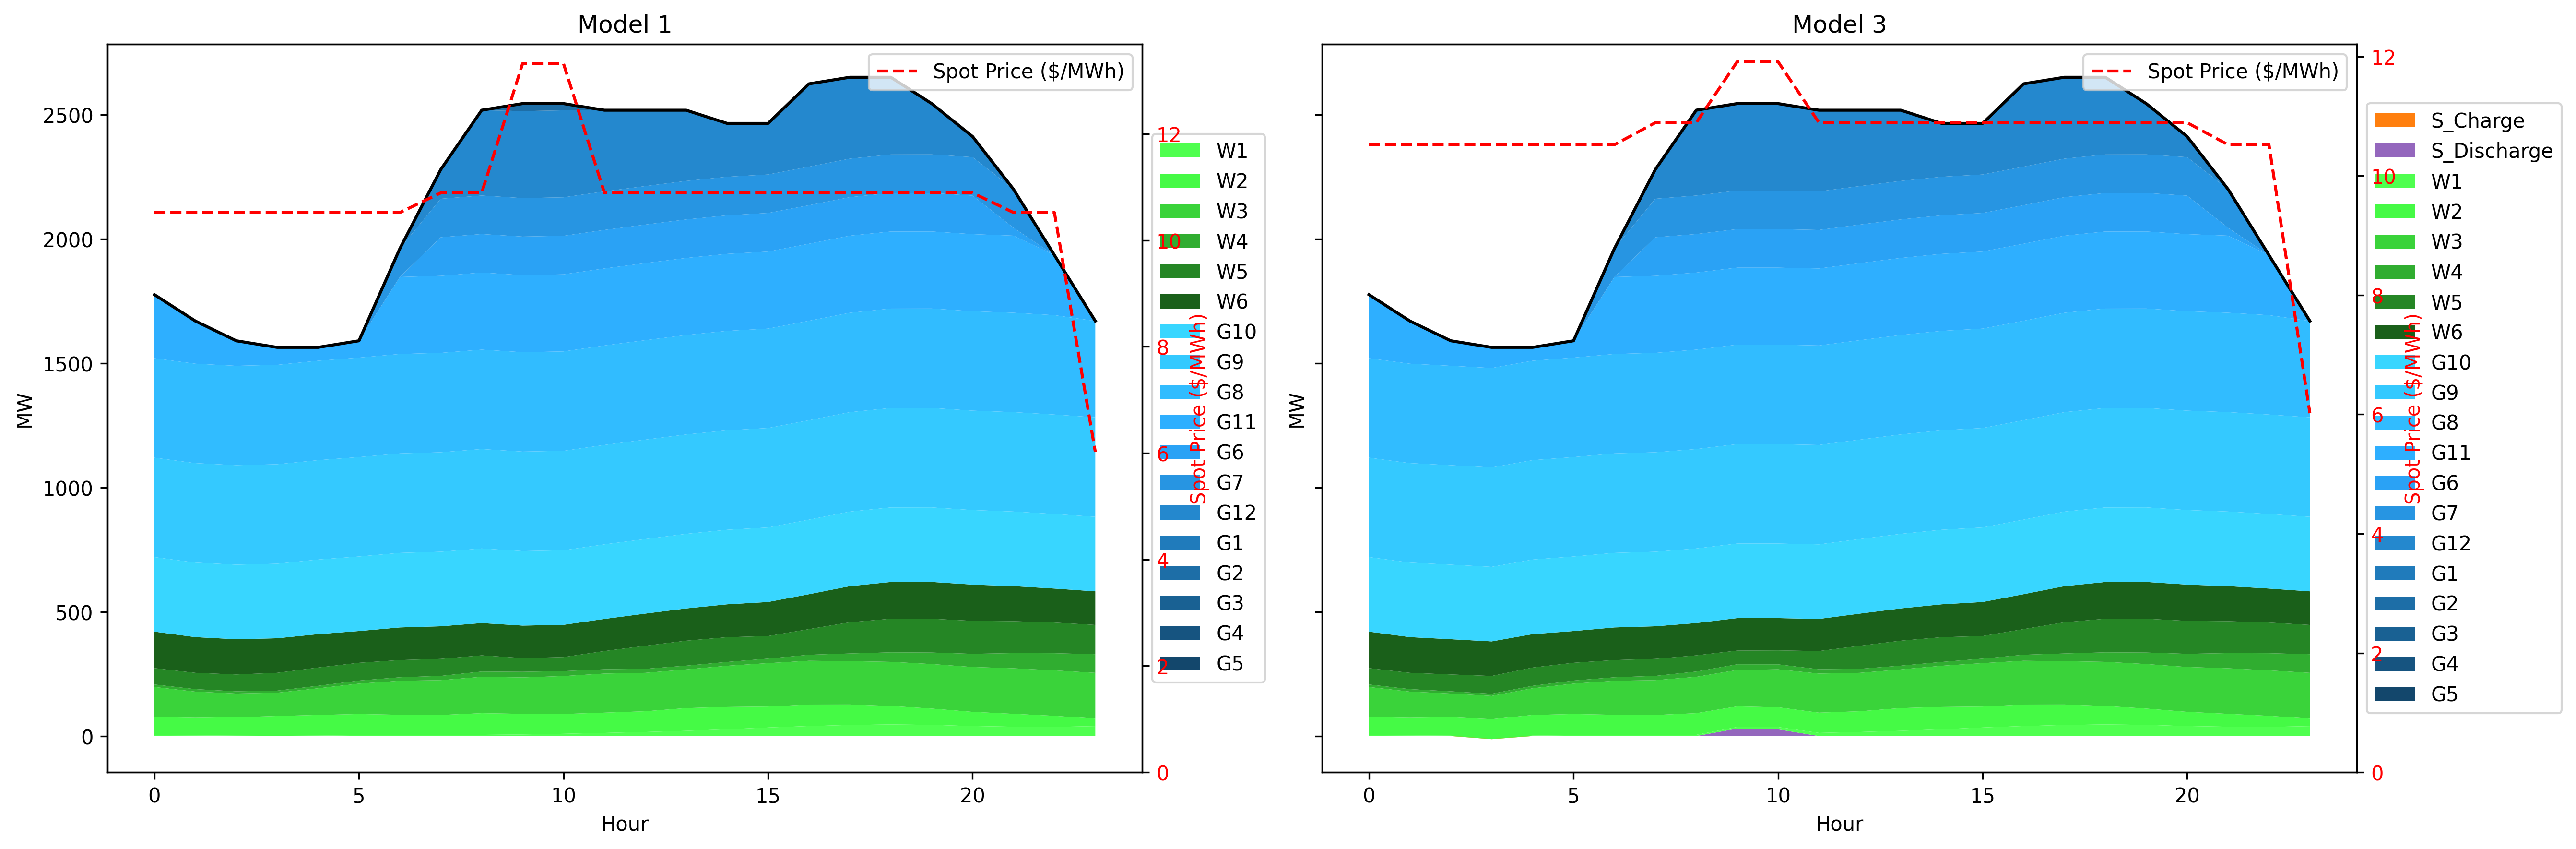

In [56]:
    # plotting the results
def dispatch_plot(model, ax):
    g_dispatch = model.variables["dispatch"].solution.to_dataframe().reset_index()
    w_dispatch = model.variables["wind_generation"].solution.to_dataframe().reset_index()
    if "storage_charge" in model.variables and "storage_discharge" in model.variables:
        storage_charge = model.variables["storage_charge"].solution.to_dataframe().reset_index()
        storage_discharge = model.variables["storage_discharge"].solution.to_dataframe().reset_index()
        storage_charge['Unit'] = 'S_Charge'
        storage_discharge['Unit'] = 'S_Discharge'
        storage_charge['solution'] = -storage_charge['solution']  # Negate charge for plotting
        dispatch_df = pd.concat([g_dispatch, w_dispatch, storage_charge, storage_discharge], ignore_index=True)
    else:
        dispatch_df = pd.concat([g_dispatch, w_dispatch], ignore_index=True)

    demand_cleared = model.variables["demand"].solution.to_dataframe().reset_index()
    total_demand = demand_cleared.groupby('Hour')['solution'].sum().rename('Total_Demand_MW').reset_index()

    spot_price = model.constraints["power_balance"].dual.to_dataframe().reset_index()
    spot_price.rename(columns={'dual': 'Spot_Price_$/MWh'}, inplace=True)

    import matplotlib.colors as mcolors

    def color_palette(unit, units_list):
        """Generate colors with different shades for units of the same type"""
        # Get base color for unit type
        if unit.startswith('G'):
            base_color = '#1f77b4'  # Professional blue (matplotlib default)
        elif unit.startswith('W'):
            base_color = '#2ca02c'  # Professional green
        elif unit == 'S_Charge':
            return '#ff7f0e'        # Professional orange
        elif unit == 'S_Discharge':
            return '#9467bd'        # Professional purple
        else:
            return '#7f7f7f'        # Professional gray
        
        # For generators and wind farms, create shades
        if unit.startswith('G'):
            same_type_units = [u for u in units_list if u.startswith('G')]
        elif unit.startswith('W'):
            same_type_units = [u for u in units_list if u.startswith('W')]
        else:
            return base_color
        
        # Get index of current unit in its type
        unit_index = same_type_units.index(unit)
        num_units = len(same_type_units)
        
        # Generate shades from light to dark
        # Use luminance range: 0.3 (dark) to 0.9 (light)
        luminance = 0.9 - (unit_index / max(num_units - 1, 1)) * 0.6
        
        # Convert base color to RGB and adjust luminance
        rgb = mcolors.to_rgb(base_color)
        adjusted_rgb = tuple(min(1.0, c * luminance / 0.5) for c in rgb)
        
        return adjusted_rgb

    # Get unique units for color assignment
    units_list = dispatch_df['Unit'].unique().tolist()

    # Apply color palette
    dispatch_df['color'] = dispatch_df['Unit'].apply(lambda x: color_palette(x, units_list))


    # Prepare data for stackplot
    dispatch_pivot = dispatch_df.pivot(index='Hour', columns='Unit', values='solution').fillna(0)
    units = dispatch_pivot.columns.tolist()
    colors = [color_palette(unit, units) for unit in units]
    # Sort units according to dispatch cost (0 for W and S, use gen_constraints for G)
    gen_constraints_df = gen_constraints.set_index('Unit')
    def unit_cost(unit):
        if unit.startswith('G'):
            return gen_constraints_df.loc[unit, 'Ci_$/MWh']+0.0001
        elif unit.startswith('W') or unit.startswith('S'):
            return 0
        else:
            return 9999  # fallback for unknown units

    units_sorted = sorted(units, key=unit_cost)
    colors_sorted = [color_palette(unit, units_sorted) for unit in units_sorted]

    ax.stackplot(dispatch_pivot.index, [dispatch_pivot[unit] for unit in units_sorted], labels=units_sorted, colors=colors_sorted)

    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    ax.plot(total_demand['Hour'], total_demand['Total_Demand_MW'], color='black', label='Total Demand')
    ax.set_xlabel('Hour')
    ax.set_ylabel('MW')

    # add another y-axis for spot price
    ax2 = ax.twinx()
    ax2.plot(spot_price['Hour'], spot_price['Spot_Price_$/MWh'], color='red', linestyle='--', label='Spot Price ($/MWh)')
    ax2.set_ylabel('Spot Price ($/MWh)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')
    ax2.set_ylim(bottom=0)  # Ensure spot price starts at 0
    

fig, axs = plt.subplots(1, 2, figsize=(18, 6), dpi=300, sharey=True)
dispatch_plot(model, axs[0])
dispatch_plot(model3, axs[1])
axs[0].set_title('Model 1')
axs[1].set_title('Model 3')
plt.tight_layout()

